# TPCRP Active Learning on CIFAR-10

Implementation of the TPCRP algorithm from:
> Hacohen et al., *Active Learning on a Budget: Opposite Strategies Suit High and Low Budgets*, ICML 2022

Comparing TPCRP against random sampling at two budget levels (B=10, B=50).

## 1. Imports

In [2]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as T
from torchvision.models import resnet18
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import TSNE
from scipy import stats
import matplotlib.pyplot as plt
from tqdm import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('using:', DEVICE)

using: cpu


## 2. SimCLR Augmentation

In [4]:
class SimCLRTransform:
    def __init__(self, size=32, s=1.0):
        self.t = T.Compose([
            T.RandomResizedCrop(size, scale=(0.2, 1.0)),
            T.RandomHorizontalFlip(),
            T.ColorJitter(0.8*s, 0.8*s, 0.8*s, 0.2*s),
            T.RandomGrayscale(p=0.2),
            T.ToTensor(),
            T.Normalize([0.4914,0.4822,0.4465],[0.2023,0.1994,0.2010]),
        ])

    def __call__(self, x):
        return self.t(x), self.t(x)

## 3. SimCLR Model

In [5]:
class ProjectionHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(512, 512), nn.ReLU(), nn.Linear(512, 128)
        )
    def forward(self, x):
        return self.net(x)


class SimCLR(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = resnet18(weights=None)
        backbone.conv1 = nn.Conv2d(3, 64, 3, 1, 1, bias=False)
        backbone.maxpool = nn.Identity()
        self.encoder = nn.Sequential(*list(backbone.children())[:-1])
        self.proj = ProjectionHead()

    def forward(self, x):
        h = self.encoder(x).flatten(1)
        return F.normalize(self.proj(h), dim=1)

## 4. NT-Xent Loss

In [ ]:
class NTXentLoss(nn.Module):
    def __init__(self, temp=0.5):
        super().__init__()
        self.temp = temp

    def forward(self, z1, z2):
        B = z1.size(0)
        z = torch.cat([z1, z2])
        sim = torch.mm(z, z.t()) / self.temp
        sim.fill_diagonal_(float('-inf'))
        labels = torch.cat([torch.arange(B, device=z.device) + B,
                             torch.arange(B, device=z.device)])
        return F.cross_entropy(sim, labels)

## 5. Train SimCLR (500 epochs)

Pre-trains on all 50k CIFAR-10 images without labels. Saves checkpoint.

In [6]:
CKPT = 'simclr.pth'

def train_simclr(epochs=500, bs=512):
    ds = torchvision.datasets.CIFAR10('./data', train=True, download=True,
                                       transform=SimCLRTransform())
    loader = DataLoader(ds, batch_size=bs, shuffle=True,
                        num_workers=12, persistent_workers=True,
                        pin_memory=True, drop_last=True)
    model = SimCLR().to(DEVICE)
    opt   = optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)
    loss_fn = NTXentLoss()
    history = []
    model.train()
    pbar = tqdm(range(1, epochs+1), desc='SimCLR')
    for ep in pbar:
        tot = 0
        for (x1, x2), _ in loader:
            x1, x2 = x1.to(DEVICE), x2.to(DEVICE)
            l = loss_fn(model(x1), model(x2))
            opt.zero_grad(); l.backward(); opt.step()
            tot += l.item()
        avg = tot / len(loader)
        history.append(avg)
        pbar.set_postfix(loss=f'{avg:.4f}')
    torch.save({'state': model.state_dict(), 'loss': history}, CKPT)
    return model, history


if os.path.exists(CKPT):
    print('loading checkpoint')
    ck = torch.load(CKPT, map_location=DEVICE)
    simclr = SimCLR().to(DEVICE)
    simclr.load_state_dict(ck['state'])
    loss_hist = ck['loss']
else:
    simclr, loss_hist = train_simclr()

loading checkpoint


## 6. Extract Embeddings

In [ ]:
def get_embeddings(model):
    norm = T.Compose([T.ToTensor(),
                      T.Normalize([0.4914,0.4822,0.4465],[0.2023,0.1994,0.2010])])
    ds = torchvision.datasets.CIFAR10('./data', train=True, download=False, transform=norm)
    loader = DataLoader(ds, batch_size=512, shuffle=False, num_workers=0)
    model.eval()
    out = []
    with torch.no_grad():
        for x, _ in loader:
            h = model.encoder(x.to(DEVICE)).flatten(1)
            out.append(F.normalize(h, dim=1).cpu())
    return torch.cat(out).numpy()


embs = get_embeddings(simclr)
print('embeddings:', embs.shape)

embeddings: (50000, 512)


## Saving to drive - commented out

In [ ]:
# from google.colab import drive
# import shutil
# import os

# # 1. Mount Google Drive
# drive.mount('/content/drive')

# drive_folder = '/content/drive/MyDrive/Colab_Checkpoints'
# os.makedirs(drive_folder, exist_ok=True)

# # 3. Copy the checkpoint to Google Drive
# local_ckpt = 'simclr.pth'
# drive_ckpt = os.path.join(drive_folder, 'simclr.pth')

# if os.path.exists(local_ckpt):
#     shutil.copy(local_ckpt, drive_ckpt)
#     print(f'Successfully backed up {local_ckpt} to Google Drive at {drive_ckpt}')
# else:
#     print(f'{local_ckpt} not found. Make sure you run the training cell first.')

Mounted at /content/drive
Successfully backed up simclr.pth to Google Drive at /content/drive/MyDrive/Colab_Checkpoints/simclr.pth


## 7. TPCRP Selection

Typicality (Eq. 4 in paper): `1 / mean_dist_to_K_neighbours`, K=20.  
At budget B: cluster unlabelled set into `min(|L|+B, 500)` clusters, skip covered clusters, pick most typical from each uncovered cluster, return top-B.

In [ ]:
def typicality(embs, k=20):
    nbrs = NearestNeighbors(n_neighbors=k+1, metric='euclidean', n_jobs=-1).fit(embs)
    d, _ = nbrs.kneighbors(embs)
    return 1.0 / (d[:, 1:].mean(axis=1) + 1e-8)


def tpcrp_select(embs, labeled, budget):
    N = len(embs)
    lab_set = set(labeled)
    unlab = np.array([i for i in range(N) if i not in lab_set])

    k = min(len(labeled) + budget, 500)
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    cl = km.fit_predict(embs[unlab])

    covered = set()
    if labeled:
        covered = set(km.predict(embs[list(labeled)]).tolist())

    typ = typicality(embs[unlab])

    best = {}
    for i, (c, t) in enumerate(zip(cl, typ)):
        if c in covered:
            continue
        idx = unlab[i]
        if c not in best or t > best[c][0]:
            best[c] = (t, idx)

    picked = [idx for _, idx in sorted(best.values(), reverse=True)][:budget]

    if len(picked) < budget:
        pool = [i for i in unlab if i not in lab_set and i not in set(picked)]
        picked += random.sample(pool, budget - len(picked))

    return picked

## 8. Baselines

**KMeans:** Cluster the unlabelled set into exactly B clusters, pick the point closest to each centroid. Pure diversity — spreads the labelled set evenly across the feature space.

**Furthest First:** Greedily pick whichever unlabelled point is furthest from all already-selected points. Another simple diversity strategy.

In [ ]:
def kmeans_select(embs, budget):
    km = KMeans(n_clusters=budget, random_state=SEED, n_init=10)
    km.fit(embs)
    picked = []
    for c in range(budget):
        dists = np.linalg.norm(embs - km.cluster_centers_[c], axis=1)
        picked.append(int(np.argmin(dists)))
    return list(dict.fromkeys(picked))[:budget]


def furthest_first_select(embs, budget):
    first = int(np.random.randint(len(embs)))
    picked = [first]
    min_dists = np.linalg.norm(embs - embs[first], axis=1)
    for _ in range(budget - 1):
        nxt = int(np.argmax(min_dists))
        picked.append(nxt)
        d = np.linalg.norm(embs - embs[nxt], axis=1)
        min_dists = np.minimum(min_dists, d)
    return picked

## 9. Train Classifier

ResNet-18 from scratch on the labelled subset (Framework 1 — no pretrained weights, no dropout).

In [ ]:
def train_clf(labeled_idx, epochs=200):
    aug = T.Compose([
        T.RandomCrop(32, padding=4), T.RandomHorizontalFlip(),
        T.ToTensor(), T.Normalize([0.4914,0.4822,0.4465],[0.2023,0.1994,0.2010]),
    ])
    norm = T.Compose([
        T.ToTensor(), T.Normalize([0.4914,0.4822,0.4465],[0.2023,0.1994,0.2010]),
    ])

    tr = Subset(torchvision.datasets.CIFAR10('./data', train=True,  download=False, transform=aug), labeled_idx)
    te =        torchvision.datasets.CIFAR10('./data', train=False, download=False, transform=norm)

    trl = DataLoader(tr, batch_size=min(64, len(labeled_idx)), shuffle=True,  num_workers=0)
    tel = DataLoader(te, batch_size=512,                       shuffle=False, num_workers=0)

    m = resnet18(weights=None)
    m.conv1  = nn.Conv2d(3, 64, 3, 1, 1, bias=False)
    m.maxpool = nn.Identity()
    m.fc     = nn.Linear(512, 10)
    m = m.to(DEVICE)

    opt  = optim.SGD(m.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
    sch  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    loss = nn.CrossEntropyLoss()

    m.train()
    for _ in range(epochs):
        for x, y in trl:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(); loss(m(x), y).backward(); opt.step()
        sch.step()

    m.eval(); c = t = 0
    with torch.no_grad():
        for x, y in tel:
            c += (m(x.to(DEVICE)).argmax(1) == y.to(DEVICE)).sum().item()
            t += y.size(0)
    return c / t

## 10. Experiments — TPCRP vs Baselines

B=10 and B=50, 10 repeats each.

In [ ]:
BUDGETS   = [10, 50]
N_REPEATS = 10
N         = 50000

res = {B: {'tpcrp': [], 'random': [], 'kmeans': [], 'furthest': []} for B in BUDGETS}

for B in BUDGETS:
    print(f'\nBudget={B}')
    for r in range(N_REPEATS):
        np.random.seed(r); random.seed(r)

        sel = tpcrp_select(embs, [], B)
        res[B]['tpcrp'].append(train_clf(sel))

        ri = np.random.choice(N, B, replace=False).tolist()
        res[B]['random'].append(train_clf(ri))

        res[B]['kmeans'].append(train_clf(kmeans_select(embs, B)))
        res[B]['furthest'].append(train_clf(furthest_first_select(embs, B)))

        print(f'  rep{r+1}  '
              f'tpcrp={res[B]["tpcrp"][-1]:.3f}  '
              f'random={res[B]["random"][-1]:.3f}  '
              f'kmeans={res[B]["kmeans"][-1]:.3f}  '
              f'ff={res[B]["furthest"][-1]:.3f}')

print('\nMeans:')
for B in BUDGETS:
    for m in ['tpcrp','random','kmeans','furthest']:
        print(f'  B={B} {m:8s} {np.mean(res[B][m]):.4f}')

import json
with open('results.json', 'w') as f:
    json.dump(res, f)
print('saved results.json')


Budget=10
  rep1  tpcrp=0.133  random=0.156  kmeans=0.158  ff=0.135
  rep2  tpcrp=0.119  random=0.129  kmeans=0.186  ff=0.151
  rep3  tpcrp=0.126  random=0.162  kmeans=0.173  ff=0.152
  rep4  tpcrp=0.130  random=0.138  kmeans=0.181  ff=0.145
  rep5  tpcrp=0.123  random=0.146  kmeans=0.182  ff=0.158
  rep6  tpcrp=0.126  random=0.156  kmeans=0.141  ff=0.128
  rep7  tpcrp=0.134  random=0.183  kmeans=0.184  ff=0.149
  rep8  tpcrp=0.152  random=0.145  kmeans=0.188  ff=0.162
  rep9  tpcrp=0.150  random=0.133  kmeans=0.162  ff=0.119
  rep10  tpcrp=0.124  random=0.141  kmeans=0.210  ff=0.173

Budget=50
  rep1  tpcrp=0.220  random=0.208  kmeans=0.216  ff=0.176
  rep2  tpcrp=0.226  random=0.209  kmeans=0.205  ff=0.200
  rep3  tpcrp=0.231  random=0.184  kmeans=0.228  ff=0.183
  rep4  tpcrp=0.223  random=0.217  kmeans=0.259  ff=0.178
  rep5  tpcrp=0.221  random=0.204  kmeans=0.218  ff=0.184
  rep6  tpcrp=0.220  random=0.214  kmeans=0.236  ff=0.163
  rep7  tpcrp=0.209  random=0.171  kmeans=0.257  

## 11. Plots

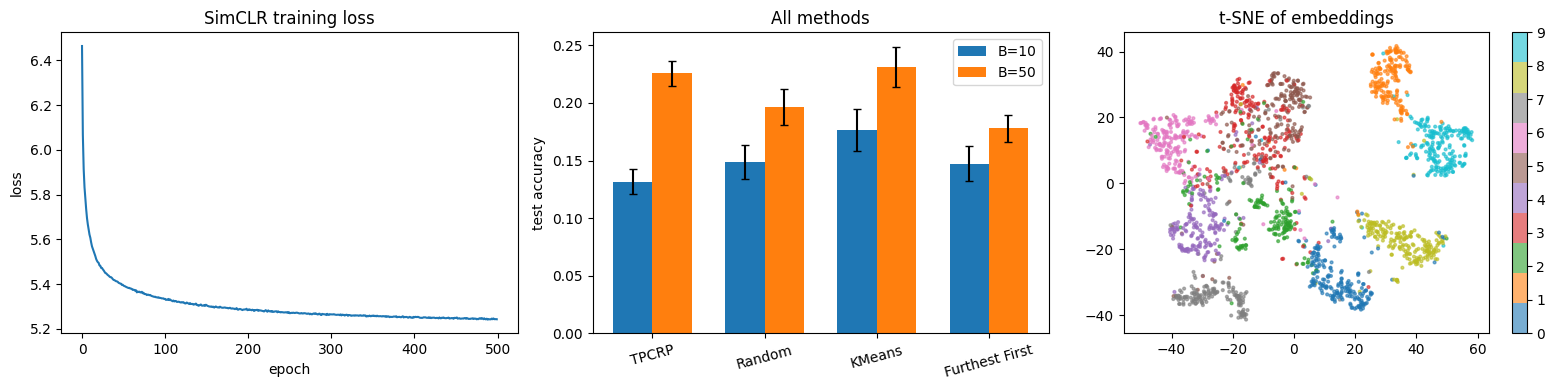

In [ ]:
methods = ['tpcrp', 'random', 'kmeans', 'furthest']
labels  = ['TPCRP', 'Random', 'KMeans', 'Furthest First']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# loss curve
axes[0].plot(loss_hist)
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss')
axes[0].set_title('SimCLR training loss')

# accuracy bars — one group per budget
x = np.arange(len(methods)); w = 0.35
for bi, B in enumerate(BUDGETS):
    offset = (bi - 0.5) * w
    means = [np.mean(res[B][m]) for m in methods]
    errs  = [np.std(res[B][m])  for m in methods]
    axes[1].bar(x + offset, means, w, yerr=errs, label=f'B={B}', capsize=3)
axes[1].set_xticks(x); axes[1].set_xticklabels(labels, rotation=15)
axes[1].set_ylabel('test accuracy'); axes[1].set_title('All methods'); axes[1].legend()

# t-SNE
idx2k = np.random.choice(len(embs), 2000, replace=False)
proj  = TSNE(n_components=2, random_state=SEED).fit_transform(embs[idx2k])
lbls  = np.array(torchvision.datasets.CIFAR10('./data', train=True, download=False, transform=T.ToTensor()).targets)
sc = axes[2].scatter(proj[:,0], proj[:,1], c=lbls[idx2k], cmap='tab10', s=4, alpha=0.6)
plt.colorbar(sc, ax=axes[2])
axes[2].set_title('t-SNE of embeddings')

plt.tight_layout()
plt.savefig('results.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Statistical Analysis

Welch's t-test comparing TPCRP against each baseline.

In [ ]:
baselines = ['random', 'kmeans', 'furthest']

for B in BUDGETS:
    print(f'B={B}  TPCRP mean={np.mean(res[B]["tpcrp"]):.4f}')
    for bl in baselines:
        t, p = stats.ttest_ind(res[B]['tpcrp'], res[B][bl], equal_var=False)
        sig = '*' if p < 0.05 else ''
        print(f'  vs {bl:8s}  mean={np.mean(res[B][bl]):.4f}  t={t:.3f}  p={p:.4f} {sig}')
    print()

B=10  TPCRP mean=0.1317
  vs random    mean=0.1489  t=-2.799  p=0.0128 *
  vs kmeans    mean=0.1764  t=-6.411  p=0.0000 *
  vs furthest  mean=0.1474  t=-2.516  p=0.0229 *

B=50  TPCRP mean=0.2256
  vs random    mean=0.1963  t=4.652  p=0.0003 *
  vs kmeans    mean=0.2312  t=-0.818  p=0.4262 
  vs furthest  mean=0.1779  t=8.867  p=0.0000 *



## 12. Task 3 — Modification: Centroid-Proximity Typicality

Instead of using KNN distances to measure typicality, I use the distance to the cluster centroid:

```
typicality(x) = 1 / ||x - centroid||
```

Points closer to their centroid are more central/representative of that cluster. This is faster than KNN (no pairwise distance matrix needed) and still captures the idea of selecting prototypical samples.

In [ ]:
def tpcrp_mod_select(embs, labeled, budget):
    N = len(embs)
    lab_set = set(labeled)
    unlab = np.array([i for i in range(N) if i not in lab_set])

    k = min(len(labeled) + budget, 500)
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    cl = km.fit_predict(embs[unlab])
    cents = km.cluster_centers_

    covered = set()
    if labeled:
        covered = set(km.predict(embs[list(labeled)]).tolist())

    dists = np.linalg.norm(embs[unlab] - cents[cl], axis=1)
    typ = 1.0 / (dists + 1e-8)

    best = {}
    for i, (c, t) in enumerate(zip(cl, typ)):
        if c in covered:
            continue
        idx = unlab[i]
        if c not in best or t > best[c][0]:
            best[c] = (t, idx)

    picked = [idx for _, idx in sorted(best.values(), reverse=True)][:budget]

    if len(picked) < budget:
        pool = [i for i in unlab if i not in lab_set and i not in set(picked)]
        picked += random.sample(pool, budget - len(picked))

    return picked


res_mod = {B: [] for B in BUDGETS}

for B in BUDGETS:
    pbar = tqdm(range(N_REPEATS), desc=f'Modified B={B}')
    for r in pbar:
        np.random.seed(r); random.seed(r)
        sel = tpcrp_mod_select(embs, [], B)
        acc = train_clf(sel)
        res_mod[B].append(acc)
        pbar.set_postfix(acc=f'{acc:.3f}')


import json
with open('results_mod.json', 'w') as f:
    json.dump(res_mod, f)
print('saved results_mod.json')

Modified B=50: 100%|██████████| 10/10 [14:25<00:00, 86.56s/it, acc=0.216]

saved results_mod.json


## 13. Task 3 — Comparison

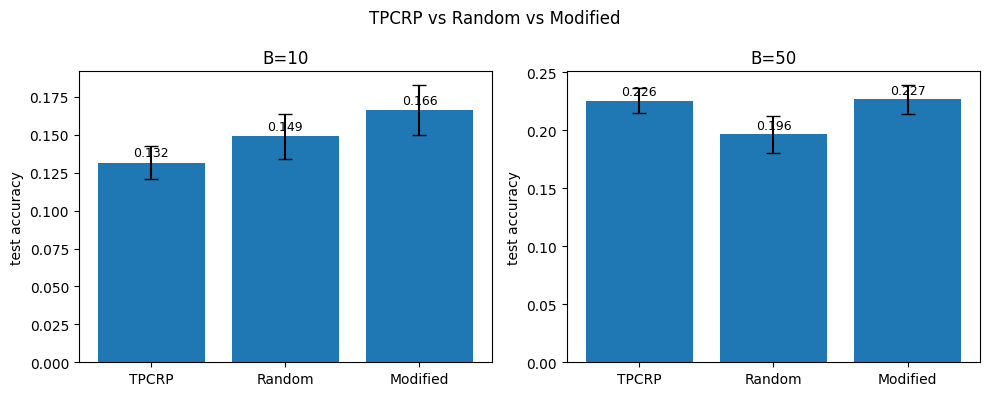

t-test: original vs modified
  B=10  t=-5.350  p=0.0001
  B=50  t=-0.181  p=0.8588


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, B in zip(axes, BUDGETS):
    m3 = ['TPCRP', 'Random', 'Modified']
    means = [np.mean(res[B]['tpcrp']), np.mean(res[B]['random']), np.mean(res_mod[B])]
    errs  = [np.std(res[B]['tpcrp']),  np.std(res[B]['random']),  np.std(res_mod[B])]
    bars = ax.bar(m3, means, yerr=errs, capsize=5)
    ax.set_title(f'B={B}'); ax.set_ylabel('test accuracy')
    for bar, m in zip(bars, means):
        ax.text(bar.get_x()+bar.get_width()/2, m+0.002, f'{m:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.suptitle('TPCRP vs Random vs Modified')
plt.tight_layout()
plt.savefig('task3.png', dpi=150, bbox_inches='tight')
plt.show()

print('t-test: original vs modified')
for B in BUDGETS:
    t, p = stats.ttest_ind(res[B]['tpcrp'], res_mod[B], equal_var=False)
    print(f'  B={B}  t={t:.3f}  p={p:.4f}')